In [1]:
import os

In [2]:
proxy = "http://cache.ha.univ-nantes.fr:3128/"

os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

In [3]:
import pandas as pd
import json, re
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display_html

# 1- Analyse générale

### Importation métriques factuelles et sémantiques

In [4]:
with open("../data/json/metrics.json","r" , encoding='utf-8') as file:
    metrics = json.load(file)

In [5]:
metrics = pd.DataFrame(metrics)
idx_drop = metrics[ ((metrics["Licence"] =="CC BY-SA 4.0")&(metrics["Domaine"]=="CHEMICAL"))].index
metrics = metrics.drop(idx_drop).reset_index(drop=True)
metrics.drop(columns=['Doi', 'Auteur', 'Date de publication', 'URL', 'Licence',
                      "Domaine",'URL / PDF', 'Sous-domaine'], inplace=True)
metrics.columns

Index(['Paragraphes', 'Rew1', 'Rew2', 'Rew3', 'BertScore1', 'BartScore1',
       'Cos_Sim1', 'FactCC1', 'FactAcc1', 'DAE1', 'FactScore1', 'BertScore2',
       'BartScore2', 'Cos_Sim2', 'FactCC2', 'FactAcc2', 'DAE2', 'FactScore2',
       'BertScore3', 'BartScore3', 'Cos_Sim3', 'FactCC3', 'FactAcc3', 'DAE3',
       'FactScore3'],
      dtype='str')

In [6]:
metrics.head(2)

,Paragraphes,Rew1,Rew2,Rew3,BertScore1,BartScore1,Cos_Sim1,FactCC1,FactAcc1,DAE1,...,FactAcc2,DAE2,FactScore2,BertScore3,BartScore3,Cos_Sim3,FactCC3,FactAcc3,DAE3,FactScore3
0,"For training, we use state-of-the-art encoder ...",Here's a rewritten version of the paragraph:\n...,Here's the rewritten paragraph without changin...,Here's the rewritten paragraph:\n\nFor trainin...,0.813151,-3.275391,0.679956,1,0.0,0.447581,...,0.333333,0.720588,0.96,0.916556,-1.134766,0.790453,0,0.833333,0.811594,0.72
1,"Cyberbullying can take many forms, with verbal...",Here's a rewritten version of the paragraph:\n...,Here's the rewritten paragraph without changin...,"Cyberbullying can manifest in various forms, w...",0.583140,-3.707031,0.523389,1,0.0,0.164234,...,1.000000,0.787546,-0.20,0.862128,-0.828613,0.975841,1,0.200000,0.675373,-0.60


### Importation des scores du LLMJ

In [7]:
with open("../data/json/llm_judgment3.json","r" , encoding='utf-8') as file:
    llmj = json.load(file)
llmj = pd.DataFrame(llmj)
llmj = llmj.drop(idx_drop).reset_index(drop=True)
llmj.columns

Index(['Doi', 'Paragraphes', 'Auteur', 'Date de publication', 'URL', 'Licence',
       'Domaine', 'Rew1', 'Rew2', 'Rew3', 'eval1', 'sem_score1', 'fact_score1',
       'eval2', 'sem_score2', 'fact_score2', 'eval3', 'sem_score3',
       'fact_score3', 'URL / PDF', 'Sous-domaine'],
      dtype='str')

In [8]:
llmj.drop(columns=['Doi', 'Paragraphes', 'Auteur', 'Date de publication', 'URL', 'Licence',
                   'Rew1', 'Rew2', 'Rew3','URL / PDF', 'Sous-domaine'], inplace=True)

In [9]:
llmj.columns

Index(['Domaine', 'eval1', 'sem_score1', 'fact_score1', 'eval2', 'sem_score2',
       'fact_score2', 'eval3', 'sem_score3', 'fact_score3'],
      dtype='str')

### Données des métriques et scores

In [10]:
data = pd.concat([metrics, llmj],axis=1)
data.columns

Index(['Paragraphes', 'Rew1', 'Rew2', 'Rew3', 'BertScore1', 'BartScore1',
       'Cos_Sim1', 'FactCC1', 'FactAcc1', 'DAE1', 'FactScore1', 'BertScore2',
       'BartScore2', 'Cos_Sim2', 'FactCC2', 'FactAcc2', 'DAE2', 'FactScore2',
       'BertScore3', 'BartScore3', 'Cos_Sim3', 'FactCC3', 'FactAcc3', 'DAE3',
       'FactScore3', 'Domaine', 'eval1', 'sem_score1', 'fact_score1', 'eval2',
       'sem_score2', 'fact_score2', 'eval3', 'sem_score3', 'fact_score3'],
      dtype='str')

In [11]:
data.shape

(120, 35)

## Summary Métriques Sémantiques et Factelles

In [12]:
import seaborn as sns

#### 1- Prompt 1

In [13]:
cols1 = [col for col in data.columns if col.endswith('1')]
data[cols1].describe(exclude=['object']).loc[["min", "max"]]

,BertScore1,BartScore1,Cos_Sim1,FactCC1,FactAcc1,DAE1,FactScore1,sem_score1,fact_score1
min,0.583140,-10.101562,0.355860,0.0,0.0,0.164234,-0.6,1.0,1.0
max,0.927934,-1.011719,0.982824,1.0,1.0,0.800000,1.0,5.0,5.0


In [14]:
data.columns

Index(['Paragraphes', 'Rew1', 'Rew2', 'Rew3', 'BertScore1', 'BartScore1',
       'Cos_Sim1', 'FactCC1', 'FactAcc1', 'DAE1', 'FactScore1', 'BertScore2',
       'BartScore2', 'Cos_Sim2', 'FactCC2', 'FactAcc2', 'DAE2', 'FactScore2',
       'BertScore3', 'BartScore3', 'Cos_Sim3', 'FactCC3', 'FactAcc3', 'DAE3',
       'FactScore3', 'Domaine', 'eval1', 'sem_score1', 'fact_score1', 'eval2',
       'sem_score2', 'fact_score2', 'eval3', 'sem_score3', 'fact_score3'],
      dtype='str')

#### 2- Prompt 2

In [15]:
cols2 = [col for col in data.columns if col.endswith('2')]
data[cols2].describe(exclude=['object']).loc[["min", "max"]]

,BertScore2,BartScore2,Cos_Sim2,FactCC2,FactAcc2,DAE2,FactScore2,sem_score2,fact_score2
min,0.757488,-6.128906,0.260750,0.0,0.0,0.319444,-0.6,1.0,1.0
max,0.991675,-0.157593,0.996623,1.0,1.0,0.987234,1.0,5.0,5.0


#### 3- Prompt 3

In [16]:
cols3 = [col for col in data.columns if col.endswith('3')]
data[cols3].describe(exclude=['object']).loc[["min", "max"]]

,BertScore3,BartScore3,Cos_Sim3,FactCC3,FactAcc3,DAE3,FactScore3,sem_score3,fact_score3
min,0.753697,-6.394531,0.353878,0.0,0.0,0.423913,-0.6,4.0,2.0
max,0.994604,-0.177734,0.999413,1.0,1.0,0.991935,1.0,5.0,5.0


#### Echelle Micro

**1- BERTScore**: “est-ce que ça veut dire la même chose ?”
  
- `Precision (P)` → les mots du rewrite sont-ils bien présents (sémantiquement) dans le source ?
- `Recall (R)` → le rewrite couvre-t-il bien le contenu du source ?
- `F1` → compromis entre les deux (le plus utilisé)

**Règle 1**
- 0.90 – 1.00 → très proche (quasi paraphrase)
- 0.80 – 0.90 → bonne similarité sémantique
- 0.70 – 0.80 → similarité moyenne
- 0.60 – 0.70 → faible similarité
- < 0.60     → très différent

  
**Analyse 1**
- Nous passons de 0.58 à 0.75 comme $\min (F1_{BERTScore})$ → amélioration de la qualité sémantique
- Nous passons de 0.93 à 0.99 comme $\max (F1_{BERTScore})$ → rapprochement optimal 

**2- BARTScore**: Prend en compte le context, la cohérence et pénalise les incohérences 

$\mathbb P(rewrite|source)$ = "est-ce que le rewrite est probable sachant le source ?"

Retour de $-loss = -cross\_entropy$ qui est la quantité de bruit (fidélité + cohérence)

**Règle 2**

- -1.0   → très bon
- -2.0   → bon
- -3.0   → moyen
- -5.0   → mauvais
- -10.0  → très mauvais

  
**Analye 2**

- Nous passons de -10 à -6 comme $\min (loss)$ → amélioration cohérence
- Nous passons de -1 à -0.1 comme $\max (loss)$ → cohérence optimale 
Les réécritures sont plus cohérents, et fidèles à mesure que nous affinons les prompts

#### Echelle Macro (similarité globale)



**3- Cosine similarity**: $\cos (source, rewrite) $ : similarité entre la source et la génération

**Règle 3**

- 0.85 – 1.00 → très proche
- 0.70 – 0.85 → similaire
- 0.50 – 0.70 → moyen
- < 0.50     → différent


**Analyse 3**


**Conclusion 1** : Métriques sémantiques

En quittant des prompts beaucoup plus général à des prompts plus spécifiques et 
pertinents, nos sommes en mesure de réduire les risques d'hallucinations, augmenter la cohérence des et d'avoir des réécritures globalement fidèles et cohérents.

**Conclusion 2** : Métriques factuelles


## Analyse Qualité Sémantique

### Analyse des métriques

#### $Nb_{x} | BertScore \geq 0.85 $

In [17]:
print(f"Prompt A: {data.loc[data["BertScore1"] >= 0.85 ].shape[0] / len(data)}  \
\t Prompt B: {data.loc[data["BertScore2"] >= 0.85 ].shape[0] / len(data)} \
\t Prompt C: {data.loc[data["BertScore3"] >= 0.85 ].shape[0] / len(data)}")

Prompt A: 0.23333333333333334  	 Prompt B: 0.8333333333333334 	 Prompt C: 0.85


Cela surgère qu'avec les prompts B et C, nous avons plus de 80% des réécritures 
qui sont sémantiquement bonnes

#### $Nb_{x} | BartScore \geq -2 $

In [18]:
print(f"Prompt A: {data.loc[data["BartScore1"] >= -2 ].shape[0] / len(data)}  \
\t Prompt B: {data.loc[data["BartScore2"] >= -2 ].shape[0] / len(data)} \
\t Prompt C: {data.loc[data["BartScore3"] >= -2 ].shape[0] / len(data)}")

Prompt A: 0.2833333333333333  	 Prompt B: 0.9083333333333333 	 Prompt C: 0.8833333333333333


72% des réécritures générés comportent des incohérences avec le prompt A
Les résulats sont plutôts meilleurs avec le prompt B (90%) et C (88%)

#### $Nb_{x} | Cos\_Sim \geq 0.85 $

In [19]:
print(f"Prompt A: {data.loc[data["Cos_Sim1"] >= 0.9 ].shape[0] / len(data)}  \
\t Prompt B: {data.loc[data["Cos_Sim2"] >= 0.9 ].shape[0] / len(data)} \
\t Prompt C: {data.loc[data["Cos_Sim3"] >= 0.9 ].shape[0] / len(data)}")

Prompt A: 0.09166666666666666  	 Prompt B: 0.225 	 Prompt C: 0.39166666666666666


Seuil 0.7: Prompt A (46%), Prompt B (71%) et Pompt C (75%)

Seuil 0.85: Prompt A (17%), Prompt B (34%) et Pompt C (47%)

Seuil 0.85: Prompt A (9%), Prompt B (22%) et Pompt C (40%)

En général, les paragraphes réécrites des prompts B et C sont globalement
sont sématiquements plus proches de celle de la source quoique faibles.

Le prompt C permet de générer plus des réécritures similaires
à la source (40%) que le prompt B.

#### Qualité sémantique: LLMJ

In [20]:
print(f"Prompt A: {Counter(data["sem_score1"])} \n \
Prompt B: {Counter(data["sem_score2"])} \n \
Prompt C: {Counter(data["sem_score3"])}")

Prompt A: Counter({5: 106, 4: 12, 1: 2}) 
 Prompt B: Counter({5: 96, 4: 18, 1: 5, 3: 1}) 
 Prompt C: Counter({5: 94, 4: 26})


Du point de vue du LLM as a judge,
Les prompts A et B générent de bonnes réécritures sémantiques,
toutefois, il existe quelque cas mauvaises générations, ce qui n'est pas
le cas avec le prompt C; qui assure d'avoir toujours des générations 
sémantiques bons.

### Analyse des transitions

#### Fonctions

In [21]:
def build_transition_matrix(df, metric="berscore"):

    # Définir les états
    data = df.copy()
    data["B_state"] = data.apply(
        lambda x: "B1" if x[metric+str(2)] > x[metric+str(1)] else "B2",
        axis=1
    )

    
    data["C_state"] = data.apply(
        lambda x: "C1" if x[metric+str(3)] > x[metric+str(2)] else "C2",
        axis=1
    )

    # Compter les transitions
    transition_counts = pd.crosstab(data["B_state"], data["C_state"])

    # Normaliser (probabilités)
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

    return transition_counts, transition_probs

In [22]:
def build_transition_matrices(df, metric="berscore", epsilon=0.0):
    
    # Définir les états
    df["B_state"] = df.apply(
        lambda x: "B1" if x[metric+str(2)] > x[metric+str(1)] else "B2",
        axis=1
    )

    
    df["C_state"] = df.apply(
        lambda x: "C1" if x[metric+str(3)] > x[metric+str(2)] else "C2",
        axis=1
    )

    df["D_state"] = df.apply(
        lambda x: "D1" if x[metric+str(3)] > x[metric+str(1)] else "D2",
        axis=1
    )

    ## TRANSITIONS: A → B → C ( A → B  VS B → C )
    # Compter les transitions
    trans_ABC = pd.crosstab(df["B_state"], df["C_state"])
    # Normaliser (probabilités)
    prob_ABC = trans_ABC.div(trans_ABC.sum(axis=1), axis=0)

    ## TRANSITIONS: A → B  VS A → C
    # Compter les transitions
    trans_ABAC = pd.crosstab(df["B_state"], df["D_state"])
    # Normaliser (probabilités)
    prob_ABAC = trans_ABAC.div(trans_ABAC.sum(axis=1), axis=0)


    return {
        "ABC": (trans_ABC, prob_ABC),
        "ABAC": (trans_ABAC, prob_ABAC),
    }

In [23]:
def display_side_by_side(df_left, df_right, title_left="Count", title_right="Prob"):
    html = f"""
    <div style="display: flex; justify-content: space-between; gap: 30px;">
        
        <div style="flex: 1;">
            <h3>{title_left}</h3>
            {df_left.to_html()}
        </div>

        <div style="flex: 1;">
            <h3>{title_right}</h3>
            {df_right.to_html()}
        </div>

    </div>
    """
    display_html(html, raw=True)

In [24]:
from IPython.display import display_html

def display_side_by_side2(dico):

    html = ""

    for name, (counts, probs) in dico.items():

        html += f"""
        <div style="margin-bottom: 25px;">
            <h3>{name}</h3>

            <div style="display: flex; gap: 40px; align-items: flex-start;">
                
                <div>
                    <h4>Counts</h4>
                    {counts.to_html()}
                </div>

                <div>
                    <h4>Probs</h4>
                    {probs.to_html()}
                </div>

            </div>
        </div>
        <hr>
        """

    display_html(html, raw=True)

In [25]:
def transition_display(df, metric="berscore"):
    count, prob = build_transition_matrix(df, metric)
    display_side_by_side(count, prob)

In [26]:
def transition_display2(df, metric="berscore"):
    results = build_transition_matrices(df, metric)
    display_side_by_side2(results)

#### Transition BERTScore

In [27]:
transition_display2(data, "BertScore")

C_state,C1,C2
B_state,,
B1,45,72
B2,3,0
C_state,C1,C2
B_state,,
B1,0.384615,0.615385
B2,1.000000,0.000000
D_state,D1,D2
B_state,,
B1,115,2


**Transition ABC**
 - $(46+72)/121 \simeq 97.5 \% $ des réécritures du prompt B sont composés
 de mots sémantiquements plus proches des mots de la source que celles 
 du prompt A.
 - 39% des générations améliorés du prompt B, le sont d'avantage avec le
   prompt C, contre 61% qui ne le sont pas.
 - La totalité du lexique des réécritures non amélirées par B (2.5%), le sont
   avec le prompt C

**Transition ABAC**

- Tout comme le prompt B, le prompt C génére des paragraphes lexicalements
- plus proches de celle de la source ($(116+2)/121 \simeq 97.5 \% $

**CONCLUSION:** Le prompt B excelle dans la génération de paragraphes
lexicalement similaires à aux paragraphes sources. 

#### Transition BARTScore

In [28]:
transition_display2(data, "BartScore")

C_state,C1,C2
B_state,,
B1,44,74
B2,2,0
C_state,C1,C2
B_state,,
B1,0.372881,0.627119
B2,1.000000,0.000000
D_state,D1,D2
B_state,,
B1,118,0


- $ (45+74)/121 \simeq 98 \% $ des générations du prompt B ont une bonne
  cohérence.
- $ (119+1)/121 \simeq 99 \% $ des générations du prompt C ont une bonne
  cohérence.
- 38% des générations améliorés en terme de cohérence du prompt B, le sont d'avantage avec le
   prompt C, contre 62% qui ne le sont pas.

**CONCLUSION:** Le prompt B excelle dans la génération de paragraphes
plus cohérentes par rapport aux contenues des paragraphes sources. 

#### Transition Cos_Sim

In [29]:
transition_display2(data, "Cos_Sim")

C_state,C1,C2
B_state,,
B1,48,36
B2,31,5
C_state,C1,C2
B_state,,
B1,0.571429,0.428571
B2,0.861111,0.138889
D_state,D1,D2
B_state,,
B1,76,8


- $ (49+36)/121 \simeq 70 \% $ des paragraphes générés du prompt B 
     sont globalement similaire (sémantiquement) aux paragraphes sources
- $ (77+20)/121 \simeq 80 \% $ des paragraphes générés du prompt C
     sont globalement similaire (sémantiquement) aux paragraphes sources
- 58% des bons cas avec le prompt C (70%), le prompts C, permet d'avoir
  des paragraphes beaucoup plus proches sémantiquement de sources.

In [30]:
sem_cols = [col for col in data.columns if col.startswith(("Be","Ba","Co", "sem"))]
sem_data = data[sem_cols]

<Axes: >

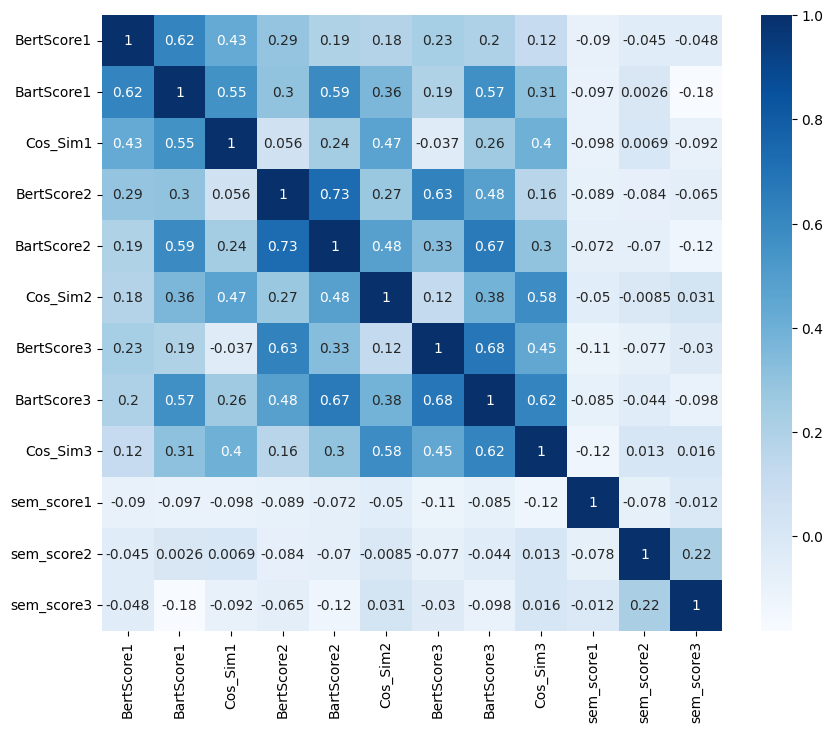

In [31]:
sem_cors = sem_data.corr()
plt.figure(figsize=(10, 8)) 
sns.heatmap(sem_cors,cmap="Blues", annot=True)

**Conclusions**:

\begin{cases}
cor(BertScore, BartScore)= 0.62  \;| \; 0.72 \; |\; 0.68 \\
cor(BertScore, Cos\_Sim)= 0.42  \;| \; 0.27 \; |\; 0.45\\
cor(BartScore, Cos\_Sim)= 0.55  \;| \; 0.48 \; |\; 0.62\\
\end{cases}

- La proximité sémantique des tokens et la cohérence des phrases sont fortement et positivemnet liées. 
- ~Le prompt 2 permet d'avoir une bonne proximité sémantique, mais n'améliore pas vraiment la cohérence.~
- ~Le prompt 3 est optimal pour améliorer la proximité sémantique des mots, la cohérence des phrases et également la similarité globale du rewrite et de la source.~

Cela justifierait pourquoi le prompt B générent globalement des paragraphes lexicalement plus proches et des phrases plus cohérentes par rapport aux sources.

## Analyse Qualité Factuelle

### Analyse des métriques

In [32]:
facts = pd.read_csv("../data/json/factscores.csv").drop(columns=["FactScore1",
                                                                 "FactScore2","FactScore3"])
facts = facts.drop(idx_drop).reset_index(drop=True)

data_fact = pd.concat([data, facts], axis=1)
data_fact.head(1)

,Paragraphes,Rew1,Rew2,Rew3,BertScore1,BartScore1,Cos_Sim1,FactCC1,FactAcc1,DAE1,...,D_state,Naive1,Naive2,Naive3,Cosine1,Cosine2,Cosine3,NLI1,NLI2,NLI3
0,"For training, we use state-of-the-art encoder ...",Here's a rewritten version of the paragraph:\n...,Here's the rewritten paragraph without changin...,Here's the rewritten paragraph:\n\nFor trainin...,0.813151,-3.275391,0.679956,1,0.0,0.447581,...,D1,0.0,0.8,0.8,1.0,1.0,1.0,0.333333,1.0,0.6


#### $Nb_{x} | FactScore(Naive) \geq 0.85 $

In [33]:
print(f"Prompt A: {data_fact.loc[data_fact['Naive1'] >= 0.85 ].shape[0] / len(data_fact)}  \
\t Prompt B: {data_fact.loc[data_fact['Naive2'] >= 0.85 ].shape[0] / len(data_fact)} \
\t Prompt C: {data_fact.loc[data_fact['Naive3'] >= 0.85 ].shape[0] / len(data_fact)}")

Prompt A: 0.1  	 Prompt B: 0.325 	 Prompt C: 0.36666666666666664


30% et plus des réécritures des prompts B et C, contiennent 85% minimum des mots contenus dans les sources.
Ce qui suggère une plus grande fidélité aux détails scientifiques (unités, quantité, etc.)

#### $Nb_{x} | FactScore(Naive) \geq 0.5 $

In [34]:
print(f"Prompt A: {data_fact.loc[data_fact['Naive1'] >= 0.5 ].shape[0] / len(data_fact)}  \
\t Prompt B: {data_fact.loc[data_fact['Naive2'] >= 0.5 ].shape[0] / len(data_fact)} \
\t Prompt C: {data_fact.loc[data_fact['Naive3'] >= 0.5 ].shape[0] / len(data_fact)}")

Prompt A: 0.3  	 Prompt B: 0.5666666666666667 	 Prompt C: 0.55


54% et plus des réécritures des prompts B et C, contiennent 54% minimum des mots contenus dans les sources.
Ce qui suggère une plus grande fidélité aux détails scientifiques (unités, quantité, etc.)

#### $Nb_{x} | FactScore(NLI) \leq 0 $

In [35]:
a = data_fact.loc[ (data_fact['NLI1'] < 0) ]
b = data_fact.loc[(data_fact['NLI2'] < 0) ]
c = data_fact.loc[(data_fact['NLI3'] < 0) ]

print(f"Prompt A: {a.shape[0] / len(data_fact)}  \
\t Prompt B: {b.shape[0] / len(data_fact)} \
\t Prompt C: {c.shape[0] / len(data_fact)}")

Prompt A: 0.31666666666666665  	 Prompt B: 0.225 	 Prompt C: 0.25


Le prompt A génèrent plus de réécritures (31%) dont les faits contredisent ceux de la source. Suivi du prompt C (25%)

#### $Nb_{x} | FactScore(NLI) \geq 0.85 $

In [36]:
a = data_fact.loc[ (data_fact['NLI1'] >= 0.85) ]
b = data_fact.loc[(data_fact['NLI2'] >= 0.85) ]
c = data_fact.loc[(data_fact['NLI3'] >= 0.85) ]

print(f"Prompt A: {a.shape[0] / len(data_fact)}  \
\t Prompt B: {b.shape[0] / len(data_fact)} \
\t Prompt C: {c.shape[0] / len(data_fact)}")

Prompt A: 0.075  	 Prompt B: 0.15 	 Prompt C: 0.11666666666666667


Le prompt B génèrent plus de réécritures ((15%)) dont les faits sont fidèles aux faits de des sources.

In [37]:
print(f"NLI: {len(data_fact.loc[(data_fact['NLI1'] < 0)])}  \
        NLI & Cosine: {len(data_fact.loc[(data_fact['NLI1'] < 0) & (data_fact['Cosine1'] < 0.85)])}  \
        NLI & Naive: {len(data_fact.loc[(data_fact['NLI1'] < 0) & (data_fact['Naive1'] < 0.85)])}")

NLI: 38          NLI & Cosine: 35          NLI & Naive: 34


In [38]:
print(f"NLI: {len(data_fact.loc[(data_fact['NLI2'] < 0)])}  \
        NLI & Cosine: {len(data_fact.loc[(data_fact['NLI2'] < 0) & (data_fact['Cosine2'] < 0.85)])}  \
        NLI & Naive: {len(data_fact.loc[(data_fact['NLI2'] < 0) & (data_fact['Naive2'] < 0.85)])}")

NLI: 27          NLI & Cosine: 19          NLI & Naive: 16


In [39]:
print(f"NLI: {len(data_fact.loc[(data_fact['NLI3'] < 0)])}  \
        NLI & Cosine: {len(data_fact.loc[(data_fact['NLI3'] < 0) & (data_fact['Cosine3'] < 0.85)])}  \
        NLI & Naive: {len(data_fact.loc[(data_fact['NLI3'] < 0) & (data_fact['Naive3'] < 0.85)])}")

NLI: 30          NLI & Cosine: 19          NLI & Naive: 15


#### $Nb_{x} | FactScore(Cosine) \geq 0.85 $

In [40]:
a = data_fact.loc[ (data_fact['Cosine1'] >= 0.85) ]
b = data_fact.loc[(data_fact['Cosine2'] >= 0.85) ]
c = data_fact.loc[(data_fact['Cosine3'] >= 0.85) ]

print(f"Prompt A: {a.shape[0] / len(data_fact)}  \
\t Prompt B: {b.shape[0] / len(data_fact)} \
\t Prompt C: {c.shape[0] / len(data_fact)}")

Prompt A: 0.14166666666666666  	 Prompt B: 0.3416666666666667 	 Prompt C: 0.31666666666666665


Dans 30% des cas, 85% des faits des réécritures, ont trouvés leurs équivalents dans les sources.

#### $Nb_{x} | FactScore \geq 0.85 $

In [41]:
print(f"Prompt A: {data_fact.loc[data_fact['FactScore1'] >= 0.85 ].shape[0] / len(data_fact)}  \
\t Prompt B: {data_fact.loc[data_fact['FactScore2'] >= 0.85 ].shape[0] / len(data_fact)} \
\t Prompt C: {data_fact.loc[data_fact['FactScore3'] >= 0.85 ].shape[0] / len(data_fact)}")

Prompt A: 0.08333333333333333  	 Prompt B: 0.15 	 Prompt C: 0.11666666666666667


In [42]:
a = data_fact.loc[(data_fact['FactScore1'] >= 0.85) & (data_fact['NLI1'] >= 0.85) ]
b = data_fact.loc[(data_fact['FactScore2'] >= 0.85) & (data_fact['NLI2'] >= 0.85) ]
c = data_fact.loc[(data_fact['FactScore3'] >= 0.85) & (data_fact['NLI3'] >= 0.85) ]

print(f"Prompt A: {a.shape[0] / len(data_fact)}  \
\t Prompt B: {b.shape[0] / len(data_fact)} \
\t Prompt C: {c.shape[0] / len(data_fact)}")

Prompt A: 0.075  	 Prompt B: 0.15 	 Prompt C: 0.11666666666666667


In [43]:
a = data_fact.loc[(data_fact['FactScore1'] >= 0.85) & (data_fact['NLI1'] >= 0.85) & 
(data_fact['Cosine1'] >= 0.85) & (data_fact['Naive1'] >= 0.85) ]
b = data_fact.loc[(data_fact['FactScore2'] >= 0.85) & (data_fact['NLI2'] >= 0.85) & 
(data_fact['Cosine2'] >= 0.85) & (data_fact['Naive2'] >= 0.85) ]
c = data_fact.loc[(data_fact['FactScore3'] >= 0.85) & (data_fact['NLI3'] >= 0.85) & 
(data_fact['Cosine3'] >= 0.85) & (data_fact['Naive3'] >= 0.85) ]


print(f"Prompt A: {a.shape[0] / len(data_fact)}  \
\t Prompt B: {b.shape[0] / len(data_fact)} \
\t Prompt C: {c.shape[0] / len(data_fact)}")

Prompt A: 0.03333333333333333  	 Prompt B: 0.11666666666666667 	 Prompt C: 0.09166666666666666


Lorsque que le FactScore est élévé (pas de perte des détails) ont est sûr que les 
faits contenus dans les réécritures sont des implications directes des faits des sources,
desquelles elles sont sémantiquements proches. Les détails scientifiques sont égalements
conservés, car 85% au minimum des détails sont conservés.

#### $Nb_{x} | FactAcc \geq 0.85 $

In [44]:
print(f"Prompt A: {data_fact.loc[data_fact["FactAcc1"] >= 0.85 ].shape[0] / len(data_fact)}  \
\t Prompt B: {data_fact.loc[data_fact["FactAcc2"] >= 0.85 ].shape[0] / len(data_fact)} \
\t Prompt C: {data_fact.loc[data_fact["FactAcc3"] >= 0.85 ].shape[0] / len(data_fact)}")

Prompt A: 0.058333333333333334  	 Prompt B: 0.5916666666666667 	 Prompt C: 0.4583333333333333


Le prompt B permet de générer des réécritures scientifiquements cohérents et globalement corrects
par rapport à la source dans pres de 59% des cas.

#### $Nb_{x} | DAE \geq 0.85 $

In [45]:
print(f"Prompt A: {data_fact.loc[data_fact["DAE1"] >= 0.85 ].shape[0] / len(data_fact)}  \
\t Prompt B: {data_fact.loc[data_fact["DAE2"] >= 0.85 ].shape[0] / len(data_fact)} \
\t Prompt C: {data_fact.loc[data_fact["DAE3"] >= 0.85 ].shape[0] / len(data_fact)}")

Prompt A: 0.0  	 Prompt B: 0.475 	 Prompt C: 0.31666666666666665


Les structures dans les faits sont plus respectées dans les générations du prompt B
Le prompt A par ne respect par les relations dans les faits de la source.

In [46]:
print(f"Prompt A: {data_fact.loc[data_fact["FactCC1"] >= 0.85 ].shape[0] / len(data_fact)}  \
\t Prompt B: {data_fact.loc[data_fact["FactCC2"] >= 0.85 ].shape[0] / len(data_fact)} \
\t Prompt C: {data_fact.loc[data_fact["FactCC3"] >= 0.85 ].shape[0] / len(data_fact)}")

Prompt A: 0.6166666666666667  	 Prompt B: 0.2833333333333333 	 Prompt C: 0.35


Le prompt A génère des paragraphes globalement plus correctes que les prompts B et C

### Analyse des transitions

### Transitions FactScore

In [47]:
transition_display2(data_fact, "FactScore")

C_state,C1,C2
B_state,,
B1,14,45
B2,19,42
C_state,C1,C2
B_state,,
B1,0.237288,0.762712
B2,0.311475,0.688525
D_state,D1,D2
B_state,,
B1,48,11


Le prompt B devance le prompt C produisant les paragraphes plus 
fidèles aux détails dans les faits

In [48]:
fact_cols = [col for col in data.columns if col.startswith(("Fa","Cosi","NL", "Na","fa"))]
fac_data = data[fact_cols]

<Axes: >

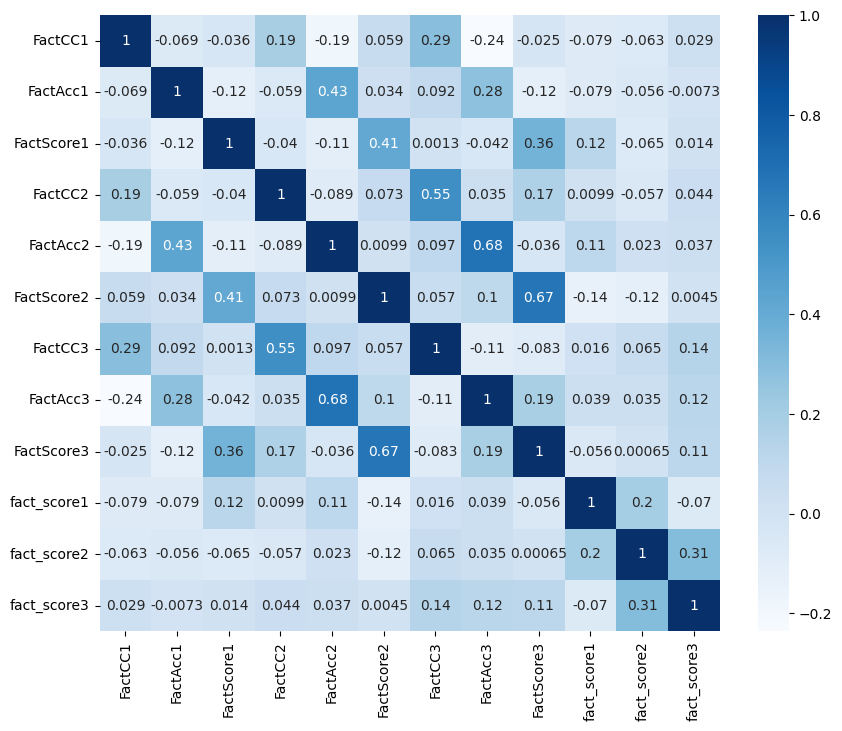

In [49]:
fac_cors = fac_data.corr()
plt.figure(figsize=(10, 8)) 
sns.heatmap(fac_cors,cmap="Blues", annot=True)

Il n'existe pas de corrélation entre les métriques factuelles différents.

# 2- Analyse de chaque domaine

In [50]:
data_fact.columns

Index(['Paragraphes', 'Rew1', 'Rew2', 'Rew3', 'BertScore1', 'BartScore1',
       'Cos_Sim1', 'FactCC1', 'FactAcc1', 'DAE1', 'FactScore1', 'BertScore2',
       'BartScore2', 'Cos_Sim2', 'FactCC2', 'FactAcc2', 'DAE2', 'FactScore2',
       'BertScore3', 'BartScore3', 'Cos_Sim3', 'FactCC3', 'FactAcc3', 'DAE3',
       'FactScore3', 'Domaine', 'eval1', 'sem_score1', 'fact_score1', 'eval2',
       'sem_score2', 'fact_score2', 'eval3', 'sem_score3', 'fact_score3',
       'B_state', 'C_state', 'D_state', 'Naive1', 'Naive2', 'Naive3',
       'Cosine1', 'Cosine2', 'Cosine3', 'NLI1', 'NLI2', 'NLI3'],
      dtype='str')

In [51]:
def filter_rewrite(text):
    
    return text.split("\n\n",1)[-1].replace("\n","").strip()

def remove_here_intro(text):
    if not isinstance(text, str):
        return text  # sécurité si NaN ou autre type

    return re.sub(r"^\s*Here.*?:\s*\n+", "", text)


In [52]:
for col in ["Rew1", "Rew2", "Rew3"]:
    data_fact[col] = data_fact[col].apply(remove_here_intro)

## TALN

In [53]:
taln = data_fact.loc[ data_fact["Domaine"] == "TALN" ]
print(len(taln))

20


In [54]:
taln[[col for col in taln.columns if col.endswith("1")]].describe().loc[["min", "max"]]

,BertScore1,BartScore1,Cos_Sim1,FactCC1,FactAcc1,DAE1,FactScore1,sem_score1,fact_score1,Naive1,Cosine1,NLI1
min,0.583140,-8.992188,0.476034,0.0,0.000000,0.164234,-0.6,5.0,4.0,0.0,0.0,-1.0
max,0.894871,-1.685547,0.896961,1.0,0.666667,0.736641,0.9,5.0,5.0,1.0,1.0,1.0


In [55]:
taln[[col for col in taln.columns if col.endswith("2")]].describe().loc[["min", "max"]]

,BertScore2,BartScore2,Cos_Sim2,FactCC2,FactAcc2,DAE2,FactScore2,sem_score2,fact_score2,Naive2,Cosine2,NLI2
min,0.811824,-3.925781,0.260750,0.0,0.0,0.319444,-0.60,4.0,4.0,0.0,0.0,-1.0
max,0.951263,-0.609863,0.981788,1.0,1.0,0.934545,0.96,5.0,5.0,1.0,1.0,1.0


In [56]:
taln[[col for col in taln.columns if col.endswith("3")]].describe().loc[["min", "max"]]

,BertScore3,BartScore3,Cos_Sim3,FactCC3,FactAcc3,DAE3,FactScore3,sem_score3,fact_score3,Naive3,Cosine3,NLI3
min,0.803529,-2.810547,0.494682,0.0,0.0,0.569966,-0.600000,4.0,4.0,0.0,0.0,-1.0
max,0.959877,-0.609863,0.976893,1.0,1.0,0.954802,0.971429,5.0,5.0,1.0,1.0,1.0


Les prompts B, C augmentent la qualité sémantique des réécritures.
- Très grande proximité lexicale des sources
- Très grande cohérence des réécritures avec les sources
- Meilleure proximité sémantique globale paragraphes

In [57]:
low_taln = taln.loc[(taln["NLI1"] < 0) | (taln["NLI2"] < 0) | (taln["NLI3"] < 0) ].reset_index(drop=True)

In [58]:
len(low_taln) / len(taln)

0.35

In [59]:
low_taln.columns

Index(['Paragraphes', 'Rew1', 'Rew2', 'Rew3', 'BertScore1', 'BartScore1',
       'Cos_Sim1', 'FactCC1', 'FactAcc1', 'DAE1', 'FactScore1', 'BertScore2',
       'BartScore2', 'Cos_Sim2', 'FactCC2', 'FactAcc2', 'DAE2', 'FactScore2',
       'BertScore3', 'BartScore3', 'Cos_Sim3', 'FactCC3', 'FactAcc3', 'DAE3',
       'FactScore3', 'Domaine', 'eval1', 'sem_score1', 'fact_score1', 'eval2',
       'sem_score2', 'fact_score2', 'eval3', 'sem_score3', 'fact_score3',
       'B_state', 'C_state', 'D_state', 'Naive1', 'Naive2', 'Naive3',
       'Cosine1', 'Cosine2', 'Cosine3', 'NLI1', 'NLI2', 'NLI3'],
      dtype='str')

In [60]:
print(f"Paragraphe: {low_taln.loc[0,'Paragraphes']}\n\
        Rewrite 1: {low_taln.loc[0,'Rew1']} \n \
        Rewrite 2: {low_taln.loc[0,'Rew2']} \n \
        Rewrite 3: {low_taln.loc[0,'Rew3']} ")

Paragraphe: Cyberbullying can take many forms, with verbal abuse being prevalent among them. It may include harassment, which involves sending repetitive and offensive messages to a target, cyberstalking (sending repetitive threatening communications), flaming, which entails sending messages containing abusive and vulgar terms such as insults, gossip, or mockery, and denigration (Bauman, 2014; Tokunaga, 2010; Watts et al., 2017). Five types commonly encountered in written language are annotated here, and these are exclusively assigned to messages identified as OAG or CAG: 1.B 1.1 Blaming (BLM): This involves making the individual believe they are responsible for the abuse they are experiencing, attributing it to their actions, words, or behavior. Example: “on la traiterait pas de truie si elle avait pas autant de graisse” (“she wouldn’t be called a pig if she didn’t have so much fat”). 1.B 1.2 Name-calling (NCG): Refers to abusive, insulting, or derogatory language aimed at undermining

In [61]:
print(f"Bert 1: {low_taln.loc[0,'BertScore1']}\
        Bart 1: {low_taln.loc[0,'BartScore1']}  \
        Cos Sim 1: {low_taln.loc[0,'Cos_Sim1']} \n\
        FactScore 1: {low_taln.loc[0,'FactScore1']} \
        FactCC 1: {low_taln.loc[0,'FactCC1']} \
        FactAcc 1: {low_taln.loc[0,'FactAcc1']} \
        DAE 1: {low_taln.loc[0,'DAE1']} \n\
        NLI 1: {low_taln.loc[0,'NLI1']}")

Bert 1: 0.5831397175788879        Bart 1: -3.70703125          Cos Sim 1: 0.5233892798423767 
        FactScore 1: -0.6         FactCC 1: 1         FactAcc 1: 0.0         DAE 1: 0.16423357664233576 
        NLI 1: -1.0


La réécriture 1, est juste un résumé de la source. On note:
- la disparition de nombreux faits contenus dans la source
- l'utilisation d'un lexique parfois éloigné du lexique de la source
- l'omission des exemples et des points au détriment d'un résumé englobant
- les faits quoique cohérent ne sont pas fidèle à la source
- la disparition des niveaux de développement (1.B 1.3)

In [62]:
print(f"Bert 2: {low_taln.loc[0,'BertScore2']}\
        Bart 2: {low_taln.loc[0,'BartScore2']}  \
        Cos Sim 2: {low_taln.loc[0,'Cos_Sim2']} \n\
        FactScore 2: {low_taln.loc[0,'FactScore2']} \
        FactCC 2: {low_taln.loc[0,'FactCC2']} \
        FactAcc 2: {low_taln.loc[0,'FactAcc2']} \
        DAE 2: {low_taln.loc[0,'DAE2']} \n\
        NLI 2: {low_taln.loc[0,'NLI2']}")

Bert 2: 0.871211051940918        Bart 2: -0.734375          Cos Sim 2: 0.8708329796791077 
        FactScore 2: -0.19999999999999998         FactCC 2: 0         FactAcc 2: 1.0         DAE 2: 0.7875457875457875 
        NLI 2: -0.6


La réécriture 2 plus cohérente, fidèle à la source.
Toutefois on note:
- Une mauvaise notation des sous-points (1.B 1.x changé en 1)
- une fidélité aux exemples de la source
- l'absence d'hallucination et de contre exemples

In [63]:
print(f"Bert 3: {low_taln.loc[0,'BertScore3']}\
        Bart 3: {low_taln.loc[0,'BartScore3']}  \
        Cos Sim 3: {low_taln.loc[0,'Cos_Sim3']} \n\
        FactScore 3: {low_taln.loc[0,'FactScore3']} \
        FactCC 3: {low_taln.loc[0,'FactCC3']} \
        FactAcc 3: {low_taln.loc[0,'FactAcc3']} \
        DAE 3: {low_taln.loc[0,'DAE3']} \n\
        NLI 3: {low_taln.loc[0,'NLI3']}")

Bert 3: 0.8621277213096619        Bart 3: -0.82861328125          Cos Sim 3: 0.9758406281471252 
        FactScore 3: -0.6         FactCC 3: 1         FactAcc 3: 0.2         DAE 3: 0.6753731343283582 
        NLI 3: -1.0


La réécriture 3 est fidèle aux unités, notations et conserve la structure de la source.
Par contre il hallucine totalement sur les exemples générant
de contre exemple d'où NLI = -1.

En conclusion, la précision sur les unités, les notations rend le modèle moins
attentif sur les autres aspects de la source générant beaucoup d'hallucination
et de contre vérité.

In [64]:
high_taln = taln.loc[(taln["NLI1"] >=0.85) | (taln["NLI2"] >=0.85) | (taln["NLI2"] >=0.85) ].reset_index(drop=True)

In [65]:
len(high_taln) / len(taln)

0.1

In [66]:
print(f"Paragraphe: {high_taln.loc[0,'Paragraphes']}\n\
        Rewrite 1: {high_taln.loc[0,'Rew1']} \n \
        Rewrite 2: {high_taln.loc[0,'Rew2']} \n \
        Rewrite 3: {high_taln.loc[0,'Rew3']} ")

Paragraphe: For training, we use state-of-the-art encoder and decoder models developed for German. As encoders, we selected three pre-trained BERT (Devlin et al., 2018) models as many previous text classification experiments make use of Transformer-based architectures (Risch et al., 2021) which have been shown to be more effective than other approaches (Struß et al., 2019). We use the base versions of the cased 10 and uncased 11 pre-trained Digitale Bibliothek Münchener Digitalisierungszentrum (DBMDZ) BERT models. The two models were trained on Wikipedia, the EU Bookshop corpus, Open Subtitles, CommonCrawl, ParaCrawl and News Crawl. Additionally, we use Deepset’s base version of the German BERT model called GBERT 12 (Chan et al., 2020).
        Rewrite 1: For training, we leverage state-of-the-art encoder and decoder models developed specifically for German, which have been shown to outperform other approaches in text classification tasks. We utilize three pre-trained BERT (Devlin et a

In [67]:
print(f"Bert 1: {high_taln.loc[0,'BertScore1']}\
        Bart 1: {high_taln.loc[0,'BartScore1']}  \
        Cos Sim 1: {high_taln.loc[0,'Cos_Sim1']} \n\
        FactScore 1: {high_taln.loc[0,'FactScore1']} \
        Naive 1: {high_taln.loc[0,'Naive1']} \
        Cosine 1: {high_taln.loc[0,'Cosine1']} \
        FactCC 1: {high_taln.loc[0,'FactCC1']} \
        FactAcc 1: {high_taln.loc[0,'FactAcc1']} \
        DAE 1: {high_taln.loc[0,'DAE1']} \n\
        NLI 1: {high_taln.loc[0,'NLI1']}")

Bert 1: 0.8131511807441711        Bart 1: -3.275390625          Cos Sim 1: 0.6799560785293579 
        FactScore 1: 0.4         Naive 1: 0.0         Cosine 1: 1.0         FactCC 1: 1         FactAcc 1: 0.0         DAE 1: 0.4475806451612903 
        NLI 1: 0.3333333333333333


- Bonne cohérence globale (Bart = -3)
- Un lexique assez synonyme (Cos Sim = 0.68) et sémantique proche de la source (Bert = 0.8)
- Une fidélité aux nombres , référence d'auteurs
- Innovation avec des phrases transitives (Naive = 0, FactScore=0.4, NLI=0.33)
- Des faits cohérents consistent globalement par rapport à la source (FactCC = 1)
- Apparition de nouveaux faits (innovation) non contenue dans la source d'où FactAcc = 0
- Une structure moyenne proche de la source (DAE = 0.44)

In [68]:
print(f"Bert 2: {high_taln.loc[0,'BertScore2']}\
        Bart 2: {high_taln.loc[0,'BartScore2']}  \
        Cos Sim 2: {high_taln.loc[0,'Cos_Sim2']} \n\
        FactScore 2: {high_taln.loc[0,'FactScore2']} \
        Naive 2: {high_taln.loc[0,'Naive2']} \
        Cosine 2: {high_taln.loc[0,'Cosine2']} \
        FactCC 2: {high_taln.loc[0,'FactCC2']} \
        FactAcc 2: {high_taln.loc[0,'FactAcc2']} \
        DAE 2: {high_taln.loc[0,'DAE2']} \n\
        NLI 2: {high_taln.loc[0,'NLI2']}")


Bert 2: 0.8744057416915894        Bart 2: -1.5224609375          Cos Sim 2: 0.6932830810546875 
        FactScore 2: 0.96         Naive 2: 0.8         Cosine 2: 1.0         FactCC 2: 0         FactAcc 2: 0.3333333333333333         DAE 2: 0.7205882352941176 
        NLI 2: 1.0


Fédélité quasi parfaite, mais omission des références d'auteurs. Il s'agit beaucoup plus d'un 
de la source avec les mêmes mots, même structures...

FactAcc instable ? (Il s'agit d'une conséquence d'une mauvaise découpe des phrases/faits)
FactCC instable suspect ([5 phrases] vs [5 phrases] → 1 seul jugement ❌ l'utilisation de 
FactCC devrait normalement être : phrase 1 vs doc → score
                                    phrase 2 vs doc → score
                                phrase 3 vs doc → score)

In [69]:
print(f"Bert 3: {high_taln.loc[0,'BertScore3']}\
        Bart 3: {high_taln.loc[0,'BartScore3']}  \
        Cos Sim 3: {high_taln.loc[0,'Cos_Sim3']} \n\
        FactScore 3: {high_taln.loc[0,'FactScore3']} \
        Naive 3: {high_taln.loc[0,'Naive3']} \
        Cosine 3: {high_taln.loc[0,'Cosine3']} \
        FactCC 3: {high_taln.loc[0,'FactCC3']} \
        FactAcc 3: {high_taln.loc[0,'FactAcc3']} \
        DAE 3: {high_taln.loc[0,'DAE3']} \n\
        NLI 3: {high_taln.loc[0,'NLI3']}")

Bert 3: 0.9165562391281128        Bart 3: -1.134765625          Cos Sim 3: 0.7904528379440308 
        FactScore 3: 0.7200000000000001         Naive 3: 0.8         Cosine 3: 1.0         FactCC 3: 0         FactAcc 3: 0.8333333333333334         DAE 3: 0.8115942028985508 
        NLI 3: 0.6000000000000001


Perfecto ! moins d'omission de référence d'auteurs que prompt B.

In [70]:
transition_display(taln, "FactScore")

C_state,C1,C2
B_state,,
B1,3,9
B2,2,6
C_state,C1,C2
B_state,,
B1,0.25,0.75
B2,0.25,0.75


## Santé

In [71]:
health = data_fact.loc[ data_fact["Domaine"] == "HEALTH"]
print(len(health))

20


In [72]:
health[[col for col in health.columns if col.endswith("1")]].describe().loc[["min", "max"]]

,BertScore1,BartScore1,Cos_Sim1,FactCC1,FactAcc1,DAE1,FactScore1,sem_score1,fact_score1,Naive1,Cosine1,NLI1
min,0.718643,-6.773438,0.414802,0.0,0.0,0.252688,-0.6,1.0,1.0,0.0,0.0,-1.0
max,0.927934,-1.011719,0.980153,1.0,1.0,0.800000,1.0,5.0,5.0,1.0,1.0,1.0


In [73]:
health[[col for col in taln.columns if col.endswith("2")]].describe().loc[["min", "max"]]

,BertScore2,BartScore2,Cos_Sim2,FactCC2,FactAcc2,DAE2,FactScore2,sem_score2,fact_score2,Naive2,Cosine2,NLI2
min,0.795356,-3.283203,0.484740,0.0,0.0,0.587879,-0.44,1.0,4.0,0.0,0.0,-1.0
max,0.966852,-0.190186,0.995965,1.0,1.0,0.987234,1.00,5.0,5.0,1.0,1.0,1.0


In [74]:
health[[col for col in taln.columns if col.endswith("3")]].describe().loc[["min", "max"]]

,BertScore3,BartScore3,Cos_Sim3,FactCC3,FactAcc3,DAE3,FactScore3,sem_score3,fact_score3,Naive3,Cosine3,NLI3
min,0.823028,-2.855469,0.373848,0.0,0.0,0.524823,-0.4,4.0,4.0,0.0,0.0,-1.0
max,0.980687,-0.255127,0.998702,1.0,1.0,0.979079,1.0,5.0,5.0,1.0,1.0,1.0


Nette amélioration de la qualité sémantique des réécritures, de leurs cohérence, de leurs qualité structurelles avec les prompts B  et C notamment selon le LLMJ

In [75]:
low_health = health.loc[(health["NLI1"] < 0) | (health["NLI2"] < 0) | (health["NLI2"] < 0) ].reset_index(drop=True)

In [76]:
len(low_health) / len(health)

0.4

In [77]:
print(f"Paragraphe: {low_health.loc[0,'Paragraphes']}\n\
        Rewrite 1: {low_health.loc[0,'Rew1']} \n \
        Rewrite 2: {low_health.loc[0,'Rew2']} \n \
        Rewrite 3: {low_health.loc[0,'Rew3']} ")

Paragraphe: We enrolled n = 38 adults (63% female, race/ethnicity: 16% Hispanic, 68% White, 24% Black, 5% Multiracial) who smoked
cigarettes daily (M = 17.2, SD = 10.9 cigarettes per day). The average age of the sample was 57.4 years old, SD = 8.5, and
most were middle aged (N = 27 45–64 years old) or older adults (N = 8 65–75 years old), who are a priority population for
tobacco treatment research [38]. Descriptive characteristics of the sample overall and by treatment group (control n = 20,
experimental n = 18) are presented in Table 1. There were no significant baseline differences between groups in any of the
cigarette use measures or key demographic variables (e.g., age, gender, race, ethnicity, employment, education, medicaid
insurance) (ps > .20). Overall, 47% of the sample had Medicaid insurance and almost all (94.7%) had a medical comorbid-
ity, most commonly hypertension, COPD or emphysema, cancer, heart disease, or diabetes.
        Rewrite 1: We enrolled 38 adults, with 63%

In [78]:
print(f"Bert 1: {low_health.loc[0,'BertScore1']}\
        Bart 1: {low_health.loc[0,'BartScore1']}  \
        Cos Sim 1: {low_health.loc[0,'Cos_Sim1']} \n\
        FactScore 1: {low_health.loc[0,'FactScore1']} \
        Naive 1: {low_health.loc[0,'Naive1']} \
        Cosine 1: {low_health.loc[0,'Cosine1']} \
        FactCC 1: {low_health.loc[0,'FactCC1']} \
        FactAcc 1: {low_health.loc[0,'FactAcc1']} \
        DAE 1: {low_health.loc[0,'DAE1']} \n\
        NLI 1: {low_health.loc[0,'NLI1']}")

Bert 1: 0.7186433672904968        Bart 1: -4.44921875          Cos Sim 1: 0.5588515996932983 
        FactScore 1: -0.6         Naive 1: 0.0         Cosine 1: 0.0         FactCC 1: 1         FactAcc 1: 0.3333333333333333         DAE 1: 0.30313588850174217 
        NLI 1: -1.0


In [79]:
print(f"Bert 2: {low_health.loc[0,'BertScore2']}\
        Bart 2: {low_health.loc[0,'BartScore2']}  \
        Cos Sim 2: {low_health.loc[0,'Cos_Sim2']} \n\
        FactScore 2: {low_health.loc[0,'FactScore2']} \
        Naive 2: {low_health.loc[0,'Naive2']} \
        Cosine 2: {low_health.loc[0,'Cosine2']} \
        FactCC 2: {low_health.loc[0,'FactCC2']} \
        FactAcc 2: {low_health.loc[0,'FactAcc2']} \
        DAE 2: {low_health.loc[0,'DAE2']} \n\
        NLI 2: {low_health.loc[0,'NLI2']}")

Bert 2: 0.9168663024902344        Bart 2: -1.34375          Cos Sim 2: 0.5945680141448975 
        FactScore 2: 0.2692307692307693         Naive 2: 0.8076923076923077         Cosine 2: 0.4230769230769231         FactCC 2: 0         FactAcc 2: 0.6666666666666666         DAE 2: 0.7752293577981652 
        NLI 2: 0.0384615384615384


In [80]:
print(f"Bert 3: {low_health.loc[0,'BertScore3']}\
        Bart 3: {low_health.loc[0,'BartScore3']}  \
        Cos Sim 3: {low_health.loc[0,'Cos_Sim3']} \n\
        FactScore 3: {low_health.loc[0,'FactScore3']} \
        Naive 3: {low_health.loc[0,'Naive3']} \
        Cosine 3: {low_health.loc[0,'Cosine3']} \
        FactCC 3: {low_health.loc[0,'FactCC3']} \
        FactAcc 3: {low_health.loc[0,'FactAcc3']} \
        DAE 3: {low_health.loc[0,'DAE3']} \n\
        NLI 3: {low_health.loc[0,'NLI3']}")

Bert 3: 0.9144331216812134        Bart 3: -1.591796875          Cos Sim 3: 0.9710216522216797 
        FactScore 3: -0.39999999999999997         Naive 3: 1.0         Cosine 3: 0.0         FactCC 3: 1         FactAcc 3: 0.3333333333333333         DAE 3: 0.6718146718146718 
        NLI 3: -1.0


Les prompts B et C ont généré des paragraphes presque identiques. La différence dans les métriques
serait due au découpement en fait qui n'est pas forcément le même.

In [81]:
high_health = health.loc[(health["NLI1"] >=0.85) | (health["NLI2"] >=0.85) | (health["NLI2"] >=0.85) ].reset_index(drop=True)

In [82]:
len(high_health)/len(health)

0.3

In [83]:
print(f"Paragraphe: {high_health.loc[0,'Paragraphes']}\n\
        Rewrite 1: {high_health.loc[0,'Rew1']} \n \
        Rewrite 2: {high_health.loc[0,'Rew2']} \n \
        Rewrite 3: {high_health.loc[0,'Rew3']} ")

Paragraphe: The study sample consisted of 50 participants, including 9 women, with a mean age of 72.7 years (SD 4.2; range 66–80). 54% of the patients were classified as ASA 3, while the remaining patients were classified as ASA 4. [25] None of the participants had a DeltaScan score greater than or equal to 3 on the day prior to the surgery. Other baseline characteristics are shown in Table 1. Table 2 presents the incidences of POD (N = 14, 28%) and POE (N = 38, 76%), as well as perioperative differences between patients with and without POD, and those with and without POE. ROC curves show that preoperative MoCA and BAMCOG poorly predict POE (AUROC of 0.59, 95% CI: 0.41-0.77 and 0.67, 95% CI: 0.50-0.85, respectively) (Fig 2). Fig 3 shows that preoperative MoCA scores had no predictive value for POD (AUROC 0.53, 95% CI: 0.33-0.73), while prediction of POD with BAMCOG was good (AUROC 0.85, 95% CI: 0.72-0.98). Logistic regression showed that higher preoperative BAMCOG scores are highly as

In [84]:
print(f"Bert 1: {high_health.loc[0,'BertScore1']}\
        Bart 1: {high_health.loc[0,'BartScore1']}  \
        Cos Sim 1: {high_health.loc[0,'Cos_Sim1']} \n\
        FactScore 1: {high_health.loc[0,'FactScore1']} \
        Naive 1: {high_health.loc[0,'Naive1']} \
        Cosine 1: {high_health.loc[0,'Cosine1']} \
        FactCC 1: {high_health.loc[0,'FactCC1']} \
        FactAcc 1: {high_health.loc[0,'FactAcc1']} \
        DAE 1: {high_health.loc[0,'DAE1']} \n\
        NLI 1: {high_health.loc[0,'NLI1']}")


Bert 1: 0.8769358396530151        Bart 1: -1.2646484375          Cos Sim 1: 0.9769132137298584 
        FactScore 1: -0.04         Naive 1: 0.0         Cosine 1: 0.0         FactCC 1: 0         FactAcc 1: 0.6666666666666666         DAE 1: 0.8 
        NLI 1: -0.0666666666666666


In [85]:
print(f"Bert 2: {high_health.loc[0,'BertScore2']}\
        Bart 2: {high_health.loc[0,'BartScore2']}  \
        Cos Sim 2: {high_health.loc[0,'Cos_Sim2']} \n\
        FactScore 2: {high_health.loc[0,'FactScore2']} \
        Naive 2: {high_health.loc[0,'Naive2']} \
        Cosine 2: {high_health.loc[0,'Cosine2']} \
        FactCC 2: {high_health.loc[0,'FactCC2']} \
        FactAcc 2: {high_health.loc[0,'FactAcc2']} \
        DAE 2: {high_health.loc[0,'DAE2']} \n\
        NLI 2: {high_health.loc[0,'NLI2']}")


Bert 2: 0.9029583930969238        Bart 2: -0.49267578125          Cos Sim 2: 0.9853169918060303 
        FactScore 2: 1.0         Naive 2: 1.0         Cosine 2: 1.0         FactCC 2: 0         FactAcc 2: 1.0         DAE 2: 0.9217391304347826 
        NLI 2: 1.0


In [86]:
print(f"Bert 3: {high_health.loc[0,'BertScore3']}\
        Bart 3: {high_health.loc[0,'BartScore3']}  \
        Cos Sim 3: {high_health.loc[0,'Cos_Sim3']} \n\
        FactScore 3: {high_health.loc[0,'FactScore3']} \
        Naive 3: {high_health.loc[0,'Naive3']} \
        Cosine 3: {high_health.loc[0,'Cosine3']} \
        FactCC 3: {high_health.loc[0,'FactCC3']} \
        FactAcc 3: {high_health.loc[0,'FactAcc3']} \
        DAE 3: {high_health.loc[0,'DAE3']} \n\
        NLI 3: {high_health.loc[0,'NLI3']}")

Bert 3: 0.9005928039550781        Bart 3: -0.359375          Cos Sim 3: 0.9855382442474365 
        FactScore 3: 1.0         Naive 3: 1.0         Cosine 3: 1.0         FactCC 3: 0         FactAcc 3: 1.0         DAE 3: 0.9482758620689655 
        NLI 3: 1.0


Les trois réécritures mettent en évidence des différences nettes en termes de fidélité au contenu scientifique, de qualité linguistique et de complétude, ce que confirment les métriques. Le Rewrite 1 conserve globalement le sens du texte source (BERTScore = 0.876, cosine ≈ 0.97), mais il perd plusieurs informations importantes comme les intervalles de confiance associés aux AUROC (par exemple 0.59, 95% CI: 0.41–0.77 pour MoCA dans la prédiction de POE), et tronque la phrase sur la régression logistique concernant l’association entre les scores BAMCOG et la réduction du risque de POD. Cette perte de détails statistiques explique la dégradation observée sur les métriques de factualité (FactScore ≈ 0, NLI négatif), malgré une bonne fluidité globale (DAE = 0.8). Le Rewrite 2, en revanche, conserve fidèlement l’ensemble des informations quantitatives et expérimentales du texte source, notamment les valeurs d’AUROC pour MoCA et BAMCOG (0.59, 0.67 pour POE ; 0.53 et 0.85 pour POD), les odds ratios (OR = 0.984, IC 95%: 0.978–0.991), ainsi que les conclusions statistiques associées, ce qui se traduit par des scores maximaux sur les métriques de factualité (FactScore = 1, NLI = 1) et une forte similarité sémantique (BERTScore ≈ 0.90). Enfin, le Rewrite 3 conserve également ces éléments clés (AUROC, OR, intervalles de confiance et conclusions statistiques), et obtient des performances similaires au Rewrite 2 en termes de fidélité locale (FactScore = 1, NLI = 1), mais il est pénalisé par une troncature en fin de phrase (« are highly… »), ce qui entraîne une perte de complétude non détectée par les métriques de factualité classiques. Ainsi, ces résultats montrent que les métriques capturent correctement la conservation des éléments quantitatifs structurants (AUROC, OR, CI), mais restent sensibles aux suppressions et insuffisantes pour détecter les problèmes de génération incomplète.

In [87]:
transition_display2(health,"FactScore")

C_state,C1,C2
B_state,,
B1,2,9
B2,2,7
C_state,C1,C2
B_state,,
B1,0.181818,0.818182
B2,0.222222,0.777778
D_state,D1,D2
B_state,,
B1,9,2


## Stats

In [88]:
stats = data_fact.loc[ data_fact["Domaine"] == "STATISTICS"].reset_index(drop=True)
print(len(stats))

20


In [89]:
stats[[col for col in stats.columns if col.endswith("1")]].describe().loc[["min", "max"]]

,BertScore1,BartScore1,Cos_Sim1,FactCC1,FactAcc1,DAE1,FactScore1,sem_score1,fact_score1,Naive1,Cosine1,NLI1
min,0.717192,-8.039062,0.478542,0.0,0.00,0.311111,-0.333333,1.0,1.0,0.0,0.0,-1.000000
max,0.880666,-1.285156,0.981258,1.0,0.75,0.649805,0.600000,5.0,5.0,1.0,1.0,0.666667


In [90]:
stats[[col for col in stats.columns if col.endswith("2")]].describe().loc[["min", "max"]]

,BertScore2,BartScore2,Cos_Sim2,FactCC2,FactAcc2,DAE2,FactScore2,sem_score2,fact_score2,Naive2,Cosine2,NLI2
min,0.777940,-4.882812,0.512513,0.0,0.0,0.417004,-0.2,1.0,1.0,0.0,0.0,-1.0
max,0.950373,-0.600586,0.976802,1.0,1.0,0.937198,1.0,5.0,5.0,1.0,1.0,1.0


In [91]:
stats[[col for col in stats.columns if col.endswith("3")]].describe().loc[["min", "max"]]

,BertScore3,BartScore3,Cos_Sim3,FactCC3,FactAcc3,DAE3,FactScore3,sem_score3,fact_score3,Naive3,Cosine3,NLI3
min,0.815620,-2.201172,0.649494,0.0,0.0,0.510949,-0.480,4.0,2.0,0.0,0.0,-1.0
max,0.984007,-0.530273,0.998045,1.0,1.0,0.936090,0.975,5.0,5.0,1.0,1.0,1.0


In [92]:
print(len(stats.loc[ stats["sem_score2"] <4])/len(stats), "\n",
    len(stats.loc[ stats["sem_score3"] <4])/len(stats))

0.05 
 0.0


In [93]:
print(len(stats.loc[ stats["sem_score2"] ==4])/len(stats), "\n",
    len(stats.loc[ stats["sem_score3"] ==4])/len(stats))

0.25 
 0.4


In [94]:
print(len(stats.loc[ stats["sem_score2"] ==5])/len(stats), "\n",
    len(stats.loc[ stats["sem_score3"] ==5])/len(stats))

0.7 
 0.6


In [95]:
print(len(stats.loc[ stats["sem_score3"] > stats["sem_score2"] ])/len(stats))
print(len(stats.loc[ stats["sem_score3"] >= stats["sem_score2"] ])/len(stats))

0.2
0.7


In [96]:
print(len(stats.loc[ stats["fact_score3"] > stats["fact_score2"] ])/len(stats))
print(len(stats.loc[ stats["fact_score3"] >= stats["fact_score2"] ])/len(stats))

0.2
0.9


Le prompt C est le meilleur pour amélirer la qualité sémantique des réécritures (LLMJ ($Sem\_Score \in 4,5$)).

In [97]:
_ = stats.loc[ stats["sem_score3"] < stats["sem_score2"] ]
print(f"Paragraphe: {_.loc[5,'Paragraphes']}\n\
        Rewrite 1: {_.loc[5,'Rew1']} \n \
        Rewrite 2: {_.loc[5,'Rew2']} \n \
        Rewrite 3: {_.loc[5,'Rew3']} ")

Paragraphe: PERSUADE 2.0 (Persuasive Essays for Rating, Selecting, and Understanding Argumentative and Discourse Elements) is a large-scale, open-source corpus designed to advance research into argumentative writing quality, discourse elements, and their effectiveness (Crossley et al., 2024). The corpus was created to address the need for systematic analysis of student argumentation and to support the development of unbiased computational algorithms for assessing writing quality. PERSUADE 2.0 builds upon the PERSUADE 1.0 corpus by adding holistic essay quality scores and effectiveness ratings for individual discourse elements. The dataset contains essays written in response to 15 different prompts across two distinct writing tasks: independent writing (8 prompts) and source-based writing (7 prompts, each with a single source text). The dataset comprises 25,996 argumentative essays written by students in grades 6-12 across the United States. The corpus reflects the diversity of the U.S.

In [98]:
print(f"Bert 1: {stats.loc[5,'BertScore1']}\
        Bart 1: {stats.loc[5,'BartScore1']}  \
        Cos Sim 1: {stats.loc[5,'Cos_Sim1']} \n\
        FactScore 1: {stats.loc[5,'FactScore1']} \
        Naive 1: {stats.loc[5,'Naive1']} \
        Cosine 1: {stats.loc[5,'Cosine1']} \
        FactCC 1: {stats.loc[5,'FactCC1']} \
        FactAcc 1: {stats.loc[5,'FactAcc1']} \
        DAE 1: {stats.loc[5,'DAE1']} \n\
        NLI 1: {stats.loc[5,'NLI1']}")
print(f"Bert 2: {stats.loc[5,'BertScore2']}\
        Bart 2: {stats.loc[5,'BartScore2']}  \
        Cos Sim 2: {stats.loc[5,'Cos_Sim2']} \n\
        FactScore 2: {stats.loc[5,'FactScore2']} \
        Naive 2: {stats.loc[5,'Naive2']} \
        Cosine 2: {stats.loc[5,'Cosine2']} \
        FactCC 2: {stats.loc[5,'FactCC2']} \
        FactAcc 2: {stats.loc[5,'FactAcc2']} \
        DAE 2: {stats.loc[5,'DAE2']} \n\
        NLI 2: {stats.loc[5,'NLI2']}")
print(f"Bert 3: {stats.loc[5,'BertScore3']}\
        Bart 3: {stats.loc[5,'BartScore3']}  \
        Cos Sim 3: {stats.loc[5,'Cos_Sim3']} \n\
        FactScore 3: {stats.loc[5,'FactScore3']} \
        Naive 3: {stats.loc[5,'Naive3']} \
        Cosine 3: {stats.loc[5,'Cosine3']} \
        FactCC 3: {stats.loc[5,'FactCC3']} \
        FactAcc 3: {stats.loc[5,'FactAcc3']} \
        DAE 3: {stats.loc[5,'DAE3']} \n\
        NLI 3: {stats.loc[5,'NLI3']}")

Bert 1: 0.7745265364646912        Bart 1: -1.6826171875          Cos Sim 1: 0.7861847877502441 
        FactScore 1: 0.19999999999999998         Naive 1: 0.1428571428571428         Cosine 1: 0.4285714285714285         FactCC 1: 1         FactAcc 1: 0.4         DAE 1: 0.6141078838174274 
        NLI 1: 0.1428571428571428
Bert 2: 0.8785721659660339        Bart 2: -0.72119140625          Cos Sim 2: 0.7208160161972046 
        FactScore 2: 0.75         Naive 2: 0.75         Cosine 2: 0.75         FactCC 2: 0         FactAcc 2: 1.0         DAE 2: 0.9345454545454546 
        NLI 2: 0.75
Bert 3: 0.8564291596412659        Bart 3: -1.0185546875          Cos Sim 3: 0.8370136618614197 
        FactScore 3: 0.6222222222222222         Naive 3: 0.6666666666666666         Cosine 3: 0.4444444444444444         FactCC 3: 0         FactAcc 3: 1.0         DAE 3: 0.863013698630137 
        NLI 3: 0.6666666666666667


Le prompt A omet les statistiques clés (x%) et les références. Le prompt B est fidèle et
prend une avance sur le prompt C qui en effet ne fait pas mension de PERSUADE et ne le définit pas.

In [99]:
_ =stats.loc[ stats["sem_score3"] > stats["sem_score2"] ]
print(f"Paragraphe: {_.loc[0,'Paragraphes']}\n\
        Rewrite 1: {_.loc[0,'Rew1']} \n \
        Rewrite 2: {_.loc[0,'Rew2']} \n \
        Rewrite 3: {_.loc[0,'Rew3']} ")

Paragraphe: I apply the framework to study SWIFT gpi adoption among Global Systemically Important Banks in 2017. SWIFT gpi represents a major technological upgrade to  interbank payment messaging, offering same-day settlement, end-to-end tracking, and confirmation of credit to beneficiary accounts. The adoption pattern provides a natural test of the framework’s predictions: banks with higher amplification factors—those more central in the combined spatial-network structure—should be earlier adopters. The empirical analysis confirms this prediction strongly (ρ = −0.69, p = 0.002), with network-central banks adopting significantly earlier than peripheral banks. Founding members, representing 29 percent of banks in the sample, account for 42 percent of total system amplification, confirming that high-amplification institutions lead adoption. Controlling for network position reveals the role of firm-level characteristics: CEO age delays adoption by 11–15 days per year conditional on firm s

In [100]:
print(f"Bert 1: {stats.loc[0,'BertScore1']}\
        Bart 1: {stats.loc[0,'BartScore1']}  \
        Cos Sim 1: {stats.loc[0,'Cos_Sim1']} \n\
        FactScore 1: {stats.loc[0,'FactScore1']} \
        Naive 1: {stats.loc[0,'Naive1']} \
        Cosine 1: {stats.loc[0,'Cosine1']} \
        FactCC 1: {stats.loc[0,'FactCC1']} \
        FactAcc 1: {stats.loc[0,'FactAcc1']} \
        DAE 1: {stats.loc[0,'DAE1']} \n\
        NLI 1: {stats.loc[0,'NLI1']}")
print(f"Bert 2: {stats.loc[0,'BertScore2']}\
        Bart 2: {stats.loc[0,'BartScore2']}  \
        Cos Sim 2: {stats.loc[0,'Cos_Sim2']} \n\
        FactScore 2: {stats.loc[5,'FactScore2']} \
        Naive 2: {stats.loc[0,'Naive2']} \
        Cosine 2: {stats.loc[0,'Cosine2']} \
        FactCC 2: {stats.loc[0,'FactCC2']} \
        FactAcc 2: {stats.loc[0,'FactAcc2']} \
        DAE 2: {stats.loc[0,'DAE2']} \n\
        NLI 2: {stats.loc[0,'NLI2']}")
print(f"Bert 3: {stats.loc[0,'BertScore3']}\
        Bart 3: {stats.loc[0,'BartScore3']}  \
        Cos Sim 3: {stats.loc[0,'Cos_Sim3']} \n\
        FactScore 3: {stats.loc[0,'FactScore3']} \
        Naive 3: {stats.loc[0,'Naive3']} \
        Cosine 3: {stats.loc[0,'Cosine3']} \
        FactCC 3: {stats.loc[0,'FactCC3']} \
        FactAcc 3: {stats.loc[0,'FactAcc3']} \
        DAE 3: {stats.loc[0,'DAE3']} \n\
        NLI 3: {stats.loc[0,'NLI3']}")

Bert 1: 0.795380711555481        Bart 1: -2.86328125          Cos Sim 1: 0.8072206377983093 
        FactScore 1: 0.6         Naive 1: 0.6666666666666666         Cosine 1: 0.3333333333333333         FactCC 1: 0         FactAcc 1: 0.2857142857142857         DAE 1: 0.4678111587982833 
        NLI 1: 0.6666666666666666
Bert 2: 0.9432621002197266        Bart 2: -0.62451171875          Cos Sim 2: 0.730217695236206 
        FactScore 2: 0.75         Naive 2: 1.0         Cosine 2: 1.0         FactCC 2: 0         FactAcc 2: 1.0         DAE 2: 0.9296482412060302 
        NLI 2: 0.1666666666666666
Bert 3: 0.9448811411857605        Bart 3: -0.91064453125          Cos Sim 3: 0.7605316638946533 
        FactScore 3: 0.0         Naive 3: 0.0         Cosine 3: 0.0         FactCC 3: 0         FactAcc 3: 0.7142857142857143         DAE 3: 0.865979381443299 
        NLI 3: 0.0


Instabilité de la métrique factuelle FactScore car les prompts B et C donne la même réécri
tures ( apply et applied est ce qui les distingue).
Ceci serait causé par la division en fait de la source et des rewrites. On peut avoir
different faits notamment pour la même source.

In [101]:
transition_display2(stats, "FactScore")

C_state,C1,C2
B_state,,
B1,3,7
B2,4,6
C_state,C1,C2
B_state,,
B1,0.3,0.7
B2,0.4,0.6
D_state,D1,D2
B_state,,
B1,8,2


## Chimie

In [102]:
chem = data_fact.loc[ data_fact["Domaine"] == "CHEMICAL"]
print(len(chem))

20


In [103]:
chem.describe().loc[["min", "max"]]

,BertScore1,BartScore1,Cos_Sim1,FactCC1,FactAcc1,DAE1,FactScore1,BertScore2,BartScore2,Cos_Sim2,...,fact_score3,Naive1,Naive2,Naive3,Cosine1,Cosine2,Cosine3,NLI1,NLI2,NLI3
min,0.735798,-5.812500,0.505033,0.0,0.0,0.279412,-0.133333,0.757488,-3.621094,0.496305,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.333333,-1.0,-1.0
max,0.899271,-1.066406,0.982824,1.0,1.0,0.722944,1.000000,0.957070,-0.157593,0.993176,...,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0


In [104]:
transition_display2(chem, "FactScore")

C_state,C1,C2
B_state,,
B1,1,6
B2,3,10
C_state,C1,C2
B_state,,
B1,0.142857,0.857143
B2,0.230769,0.769231
D_state,D1,D2
B_state,,
B1,5,2


## Economie

In [105]:
eco = data_fact.loc[ data_fact["Domaine"] == "ECONOMICS  FINANCE"]
print(len(eco))

20


In [106]:
eco.describe().loc[["min", "max"]]

,BertScore1,BartScore1,Cos_Sim1,FactCC1,FactAcc1,DAE1,FactScore1,BertScore2,BartScore2,Cos_Sim2,...,fact_score3,Naive1,Naive2,Naive3,Cosine1,Cosine2,Cosine3,NLI1,NLI2,NLI3
min,0.696189,-10.101562,0.397359,0.0,0.000000,0.218519,-0.3,0.772865,-6.128906,0.358535,...,3.0,0.000000,0.0,0.0,0.0,0.0,0.0,-0.5,-1.0,-1.0
max,0.869355,-1.767578,0.978200,1.0,0.833333,0.610000,0.9,0.991675,-0.621582,0.996623,...,5.0,0.833333,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [107]:
transition_display2(eco, "FactScore")

C_state,C1,C2
B_state,,
B1,2,7
B2,4,7
C_state,C1,C2
B_state,,
B1,0.222222,0.777778
B2,0.363636,0.636364
D_state,D1,D2
B_state,,
B1,9,0


## Computer Science

In [108]:
comp = data_fact.loc[ data_fact["Domaine"] == "COMPUTER SCIENCE"]
print(len(comp))

20


In [109]:
comp.describe().loc[["min", "max"]]

,BertScore1,BartScore1,Cos_Sim1,FactCC1,FactAcc1,DAE1,FactScore1,BertScore2,BartScore2,Cos_Sim2,...,fact_score3,Naive1,Naive2,Naive3,Cosine1,Cosine2,Cosine3,NLI1,NLI2,NLI3
min,0.669772,-6.468750,0.355860,0.0,0.0,0.256917,-0.16,0.817009,-2.609375,0.498290,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.6,-1.0,-0.571429
max,0.916642,-1.104492,0.869941,1.0,1.0,0.757322,1.00,0.954081,-0.437988,0.989523,...,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000


In [110]:
transition_display2(comp,"FactScore")

C_state,C1,C2
B_state,,
B1,3,7
B2,4,6
C_state,C1,C2
B_state,,
B1,0.3,0.7
B2,0.4,0.6
D_state,D1,D2
B_state,,
B1,8,2
